In [33]:
# will need GPU to generate model embeddings

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-fbdc2a7b-c9f5-5e02-17f9-4e00342e866c"

In [34]:
import numpy as np
from collections import defaultdict, Counter
import torch
from sklearn.decomposition import PCA

import scipy
from scipy.stats import spearmanr
from scipy.stats import permutation_test
from sklearn.linear_model import LogisticRegression

import sys
sys.path.append("../2_train_models")
from data_loading import extract_peaks
from file_configs import MergedFilesConfig, FoldFilesConfig
from file_configs_promoters_only import PromotersOnlyFoldFilesConfig
from BPNet_strand_merged_umap import Model

sys.path.append("../5_modisco")
from modiscolite_utils import load_observed_profiles, load_modisco_results

from common_functions import load_coords
from load_annotations_utils import find_peak_overlap_labels, get_ccre_bed
from motif_hits_utils import load_motif_hits
from other_motif_utils import trim_motif_by_thresh

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

%matplotlib inline

In [35]:
# specify what set of models to look at
cell_type = "K562"

# the unique IDs for each of the folds / models in this cell type
timestamps = ["2023-05-29_15-51-40",
              "2023-05-29_15-58-41",
              "2023-05-29_15-59-09",
              "2023-05-30_01-40-06",
              "2023-05-29_23-21-23",
              "2023-05-29_23-23-45",
              "2023-05-29_23-24-11"]

# these usually don't change
model_type = "strand_merged_umap"
data_type = "procap"

# size of the model inputs and outputs
in_window = 2114
out_window = 1000

# motif names below are specific to the K562 profile modisco run
motif_names = ["SP1/BRE", "CA-Inr", "ETS", "NFY", "NRF1", "ATF1", "TATA",
               "THAP11", "YY1", "AP1", "TA-Inr", "CTCF", "ZBTB33", "TCT", "TATATA"]

# what subset of the modisco results to look at (aligns with names)
patterns_to_keep = [0,1,2,3,4,5,6,7,8,9,13,15,19,21,23]

In [36]:
# Load the config object (filepaths holder) for when model outputs were merged across all folds

config = MergedFilesConfig(cell_type, model_type, data_type)

# these paths aren't specific to any model / fold, cell type, or data_type

proj_dir = config.proj_dir

figures_dir = proj_dir + "figures_final/"
os.makedirs(figures_dir, exist_ok=True)

In [37]:
coords = load_coords(config.all_peak_path, in_window=in_window)

In [38]:
# essentially, run bedtools intersect between PRO-cap peaks and cCRE annotations
# (takes a second to run)

# cCRE annotations are cell-type-specific, from ENCODE 2020 paper:
#  "Expanded encyclopaedias of DNA elements in the human and mouse genomes." (Nature)

ccre_annots = find_peak_overlap_labels(coords, get_ccre_bed(cell_type, proj_dir),
                                       in_window, out_window)

# break down category of "promoter" (PLS) into promoters
# with vs. without proximal enhancers (pELS)

ccre_annots["PLS_no_pELS"] = ccre_annots["PLS"] * (~ ccre_annots["pELS"])
ccre_annots["PLS_with_pELS"] = ccre_annots["PLS"] * ccre_annots["pELS"]

In [39]:
# load in sequences and observed data at all PRO-cap peaks

onehot_seqs, true_profs = extract_peaks(config.genome_path,
                                        config.chrom_sizes,
                                        config.plus_bw_path,
                                        config.minus_bw_path,
                                        config.all_peak_path,
                                        in_window=in_window,
                                        out_window=out_window,
                                        max_jitter=0,
                                        verbose=True)

true_counts = true_profs.sum(axis=(1,2))  # summing across strands and genomic axis

Loading genome sequence from /mnt/lab_data2/kcochran/procapnet/genomes/hg38.withrDNA.fasta


Reading FASTA: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:07<00:00,  3.33it/s]
Loading Peaks: 30534it [00:37, 804.80it/s]


== In Extract Peaks ==
Peak filepath: /mnt/lab_data2/kcochran/procapnet/data/procap/processed/K562/peaks.bed.gz
Sequence length (with jitter): 2114
Profile length (with jitter): 1000
Max jitter applied: 0
Num. Examples: 30534
Mask loaded? False


In [40]:
# load model predictions for all peaks (generated by scripts in 3_eval_models/ folder)

pred_profs = np.exp(np.load(config.pred_profiles_all_path))
pred_counts = np.exp(np.load(config.pred_logcounts_all_path)).squeeze()

## Figure 4A: Model Embeddings

In [26]:
# re-define the model's forward func so that it returns output of intermediate layer

class BPNet_Embeddings_Loader(Model):
    def __init__(self, n_filters=512, n_layers=8, trimming=(in_window - out_window) // 2,
                 alpha=100):
        super().__init__("", n_filters=n_filters, n_layers=n_layers, trimming=trimming,
                         alpha=alpha)

    def forward(self, X):
        start, end = self.trimming, X.shape[2] - self.trimming

        X = self.relus[0](self.iconv(X))

        for i in range(self.n_layers):
            X_conv = self.relus[i+1](self.rconvs[i](X))
            X = torch.add(X, X_conv)
            
        X = X[:, :, start - self.deconv_kernel_size//2 : end + self.deconv_kernel_size//2]

        # return result of global avg pooling
        # (beginning of counts head, before linear layer)
        X = torch.mean(X, axis=2)
        return X
    
    
def get_embeddings(embedder, seqs, batch_size=128):
    # expecting seqs to be (num_peaks x 4 x sequence_length) array
    
    # if last two axes are transposed, fix
    if not seqs.shape[-2] == 4:
        seqs = np.swapaxes(seqs, -2, -1)
        
    # in batches, push sequences through the model, and collect embeddings
    # (takes about a minute on an A100)
    
    seqs = torch.tensor(seqs, dtype=torch.float)
    embedder = embedder.cuda()
    with torch.no_grad():
        starts = np.arange(0, seqs.shape[0], batch_size)
        ends = starts + batch_size

        embeds = []
        for i, (start, end) in enumerate(zip(starts, ends)):
            if i % 50 == 0:
                print("Batch " + str(i) + " of " + str(len(starts)))
            
            seqs_batch = seqs[start:end]
            embeds_batch = embedder(seqs_batch.cuda()).cpu().detach().numpy()
            embeds.append(embeds_batch)

    embedder = embedder.cpu()
    return np.concatenate(embeds)

def get_embeddings_all_folds(cell_type, timestamps, seqs, model_type=model_type, data_type=data_type):
    embeddings_all_folds = []
    
    for timestamp in timestamps:
        # fold # doesn't matter if you're just accessing the model by timestamp, so "1"
        fold_config = FoldFilesConfig(cell_type, model_type, "1", timestamp, data_type)
        
        # init the embeddings-output version of the model
        embedder = BPNet_Embeddings_Loader()
        # load the original trained model for this fold
        model = torch.load(fold_config.model_save_path)
        # copy model parameters over from the trained model to the embeddings-outputter
        embedder.load_state_dict(model.state_dict())
        embedder.eval()
        embedder = embedder.cuda()
        
        embeddings_all_folds.append(get_embeddings(embedder, seqs))
        
    return np.array(embeddings_all_folds).mean(axis=0)

all_embeds = get_embeddings_all_folds(cell_type, timestamps, onehot_seqs)

Timestamp: 2023-05-29_15-51-40


/tmp/ipykernel_681212/2188739490.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(fold_config.model_save_path)


Batch 0 of 239
Batch 50 of 239
Batch 100 of 239
Batch 150 of 239
Batch 200 of 239
Timestamp: 2023-05-29_15-58-41
Batch 0 of 239
Batch 50 of 239
Batch 100 of 239
Batch 150 of 239
Batch 200 of 239
Timestamp: 2023-05-29_15-59-09
Batch 0 of 239
Batch 50 of 239
Batch 100 of 239
Batch 150 of 239
Batch 200 of 239
Timestamp: 2023-05-30_01-40-06
Batch 0 of 239
Batch 50 of 239
Batch 100 of 239
Batch 150 of 239
Batch 200 of 239
Timestamp: 2023-05-29_23-21-23
Batch 0 of 239
Batch 50 of 239
Batch 100 of 239
Batch 150 of 239
Batch 200 of 239
Timestamp: 2023-05-29_23-23-45
Batch 0 of 239
Batch 50 of 239
Batch 100 of 239
Batch 150 of 239
Batch 200 of 239
Timestamp: 2023-05-29_23-24-11
Batch 0 of 239
Batch 50 of 239
Batch 100 of 239
Batch 150 of 239
Batch 200 of 239


In [27]:
pca = PCA(n_components=10)
pcs = pca.fit(all_embeds)

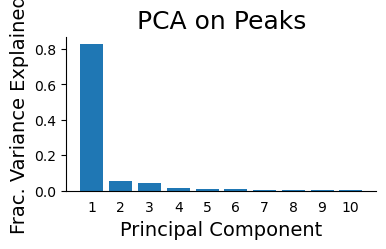

In [28]:
def plot_pc_frac_variances(pca_object):
    plt.figure(figsize=(4,2))
    plt.bar(range(1, 10+1), pca_object.explained_variance_ratio_)
    plt.xlabel("Principal Component", fontsize = 14)
    plt.ylabel("Frac. Variance Explained", fontsize = 14)
    plt.title("PCA on Peaks", fontsize = 18)

    plt.xticks(range(1, 10+1))
    plt.gca().spines[["right", "top"]].set_visible(False)
    plt.gca().xaxis.set_ticks_position('none') 

    plt.show()
    
plot_pc_frac_variances(pca)

In [29]:
sum(pca.explained_variance_ratio_[:2])

0.8835218548774719

In [30]:
all_embeds_pca_trans = pca.transform(all_embeds)

embeds_pca_trans = dict()
for annot_label in ["PLS", "PLS_with_pELS", "PLS_no_pELS", "dELS"]:
    embeds_pca_trans[annot_label] = all_embeds_pca_trans[ccre_annots[annot_label]]

In [31]:
def get_balanced_sample_bools(arr):
    # returns a binary mask array of what elements in arr to keep,
    # in order to balance the array
    
    assert len(arr.shape) == 1, arr.shape # expecting 1D vector
    assert len(set(arr)) == 2, set(arr) # expecting binary labels
    
    minority_label = Counter(arr).most_common()[-1][0]
    
    # make True-False masks of samples
    minority_samples_bools = arr == minority_label
    majority_samples_bools = arr != minority_label
    
    
    ### randomly choose [num minority samples] samples from the majority class
    
    how_many_to_subsample = np.sum(minority_samples_bools)
    print("Subsampling " + str(how_many_to_subsample) + " samples from " + str(np.sum(majority_samples_bools)))
    assert len(np.where(majority_samples_bools)[0]) == np.sum(majority_samples_bools)
    
    # get indexes of majority-class samples we want to keep
    majority_subsample_idxs = np.random.choice(np.where(majority_samples_bools)[0],
                                               size=how_many_to_subsample,
                                               replace=False)
    # convert list of indexes to True-False mask
    majority_subsample_bools = np.array([i in majority_subsample_idxs for i in range(len(arr))])
    
    # then, our final set is [all minority samples] + [subsetted majority samples]
    to_keep = np.logical_or(minority_samples_bools, majority_subsample_bools)
    return to_keep


# try fitting a logistic regression model to predict promoter vs. enhancer
# using PCA of embeddings

def get_pca_ccre_classifier_acc(all_embeds_pca_trans, ccre_annots, fold_labels_all = fold_labels):
    either_promoter_or_enhancer_peaks = np.logical_or(ccre_annots["PLS"], ccre_annots["dELS"])
    
    predictor_array = all_embeds_pca_trans[either_promoter_or_enhancer_peaks]
    to_predict = ccre_annots["PLS"][either_promoter_or_enhancer_peaks]
    
    fold_labels = fold_labels_all[either_promoter_or_enhancer_peaks]

    # (data is imbalanced: 75% of PRO-cap peaks are promoters vs. annotated distal enhancers,
    # though that might just mean our enhancer annotations are limited or mostly "proximal")
    print("Entire dataset stats:", len(to_predict), "promoters-or-distal-enhancers total")
    print("Num promoters:", to_predict.sum())
    print("Num distal enhancers:", (1 - to_predict).sum())
    print("Fraction of entire dataset that is promoters:", np.mean(to_predict))
    
    fold_accs_imbalanced = []
    fold_accs_balanced = []
    for fold_i in sorted(list(set(fold_labels))):
        print("FOLD:", fold_i + 1)
        assert len(to_predict) == len(fold_labels), (len(to_predict), len(fold_labels))
        assert len(predictor_array) == len(fold_labels), (len(predictor_array), len(fold_labels))
        
        to_predict_train = to_predict[fold_labels != fold_i]
        to_predict_test = to_predict[fold_labels == fold_i]
        predictor_array_train = predictor_array[fold_labels != fold_i]
        predictor_array_test = predictor_array[fold_labels == fold_i]

        print("Fold test set size:", len(to_predict_test))
        print("Fold test set promoters:", to_predict_test.sum())
        print("Fold test set distal enhancers:", (1 - to_predict_test).sum())
        
        lrm = LogisticRegression(penalty=None).fit(predictor_array_train, to_predict_train)
        
        acc = lrm.score(predictor_array_test, to_predict_test)
        fold_accs_imbalanced.append(acc)
        
        # repeat, but with test set balanced
        # (since balancing the test set uses random sampling, repeat and average)
        accs_rand = []
        for _ in range(5):
            balanced_test_mask = get_balanced_sample_bools(to_predict_test)
            to_predict_test_balanced = to_predict_test[balanced_test_mask]
            predictor_array_test_balanced = predictor_array_test[balanced_test_mask]
        
            acc = lrm.score(predictor_array_test_balanced, to_predict_test_balanced)
            accs_rand.append(acc)
            
        fold_accs_balanced.append(np.mean(accs_rand))

    return np.mean(fold_accs_imbalanced), np.mean(fold_accs_balanced)


def plot_embeds_pca(embeds_pca, fracs_var_explained, save_path = None, title_suffix = None):
    annots_to_plot = ["PLS", "dELS"]
    annots_to_colors = {"PLS" : "#f94144", "dELS" : "#05668d"}
    annots_to_names = {"PLS" : "Promoters", "dELS" : "Distal Enhancers"}
    
    for pc_i, pc_j in [(0,1), (2,3), (4,5), (6,7)]:
        plt.figure(figsize=(2.5,1.5), dpi=300)

        legend_elements = []
        for annot in annots_to_plot:
            plt.scatter(embeds_pca[annot][..., pc_i], embeds_pca[annot][..., pc_j],
                        alpha = 0.1, s = 2, c=annots_to_colors[annot], linewidths=0, rasterized=True)

            # make a custom dot for the legend
            # (needed because of how low-opacity the scatter dots are)
            legend_dot = Line2D([0], [0], label = annots_to_names[annot],
                                markerfacecolor = annots_to_colors[annot],
                                marker = 'o', color = 'w',
                                markersize = 7)
            legend_elements.append(legend_dot)


        plt.xlabel("PC " + str(pc_i + 1) + " (%0.2f" % (fracs_var_explained[pc_i] * 100) + "% Variance)",
                   fontsize = 7.5)
        plt.ylabel("PC " + str(pc_j + 1) + " (%0.2f" % (fracs_var_explained[pc_j] * 100) + "% Variance)",
                   fontsize = 7.5)
        
        title = "ProCapNet Embeddings"
        print("title_suffix", title_suffix)
        if title_suffix != None:
            title += title_suffix
        plt.title(title, fontsize = 9)

        # aesthetics

        plt.gca().spines[["left", "bottom"]].set_linewidth(1)
        plt.gca().spines[["right", "top"]].set_visible(False)
        plt.tick_params("both", length=2, pad=2, labelsize = 6.5)

        # default plots too many ticks?
        #xticks = plt.gca().get_xticks()
        #plt.xticks([-0.8, -0.4, 0, 0.4, 0.8])

        #yticks = plt.gca().get_yticks()
        #plt.yticks([-0.2, 0, 0.2, 0.4])

        plt.legend(handles=legend_elements, fontsize = 7, ncol=2, handletextpad=0.1,
                   loc='upper center', bbox_to_anchor = (0.49, -0.27))

        if save_path is not None:
            plt.savefig(save_path.replace(".pdf", "_pcs_" + str(pc_i + 1) + "_" + str(pc_j + 1) + ".pdf"),
                        bbox_inches = 'tight', pad_inches = 0, dpi = 300, transparent=True)
        else:
            plt.show()


all_embeds_pca_trans_by_annot = dict()
for annot_label in ["PLS", "PLS_with_pELS", "PLS_no_pELS", "dELS"]:
    all_embeds_pca_trans_by_annot[annot_label] = all_embeds_pca_trans[ccre_annots[annot_label]]

print("Frac. Variance Explained by PCs:")
print(pca.explained_variance_ratio_[:5], "PC1 + PC2:", sum(pca.explained_variance_ratio_[:2]))

plot_embeds_pca(all_embeds_pca_trans_by_annot,
                pca.explained_variance_ratio_,
                save_path = figures_dir + "3A_embeds_lastlayer.pdf")


acc = get_pca_ccre_classifier_acc(all_embeds_pca_trans, ccre_annots)

print("Accuracy of LR classifier (promoter vs. enhancer), unbalanced and balanced:", acc)

Frac. Variance Explained by PCs:
[0.8276359  0.05588597 0.04243328 0.0162767  0.01197496] PC1 + PC2: 0.8835218548774719
title_suffix None
title_suffix None
title_suffix None
title_suffix None
Entire dataset stats: 22608 promoters-or-distal-enhancers total
Num promoters: 16960
Num distal enhancers: 5648
Fraction of entire dataset that is promoters: 0.7501769285208776
FOLD: 1
Fold test set size: 3141
Fold test set promoters: 2351
Fold test set distal enhancers: 790
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
FOLD: 2
Fold test set size: 2775
Fold test set promoters: 2157
Fold test set distal enhancers: 618
Subsampling 618 samples from 2157
Subsampling 618 samples from 2157
Subsampling 618 samples from 2157
Subsampling 618 samples from 2157
Subsampling 618 samples from 2157
FOLD: 3
Fold test set size: 3314
Fold test set promoters: 2350
Fold test set distal enhancers

## Figure 4B-4C: Motif Frequency in cCREs

In [41]:
# load motif hits

motif_hits, _, motif_hit_counts = load_motif_hits(cell_type, model_type, data_type,
                                                  in_window=in_window)

num_peaks: 30534
num peaks with motif: SP1/BRE 24283
num_overlap_peaks_with_motif SP1/BRE PLS 15084
num_overlap_peaks_with_motif SP1/BRE dELS 3907
[[1876, 15084], [1741, 3907]]
Fishers exact p-val: SP1/BRE 4.37993585373441e-242
num peaks with motif: CA-Inr 21445
num_overlap_peaks_with_motif CA-Inr PLS 12045
num_overlap_peaks_with_motif CA-Inr dELS 3992
[[4915, 12045], [1656, 3992]]
Fishers exact p-val: CA-Inr 0.6237619752418524
num peaks with motif: ETS 12895
num_overlap_peaks_with_motif ETS PLS 8090
num_overlap_peaks_with_motif ETS dELS 2149
[[8870, 8090], [3499, 2149]]
Fishers exact p-val: ETS 8.562935994223057e-37
num peaks with motif: NFY 10754
num_overlap_peaks_with_motif NFY PLS 6380
num_overlap_peaks_with_motif NFY dELS 1746
[[10580, 6380], [3902, 1746]]
Fishers exact p-val: NFY 5.76983757785211e-20
num peaks with motif: NRF1 9961
num_overlap_peaks_with_motif NRF1 PLS 7679
num_overlap_peaks_with_motif NRF1 dELS 871
[[9281, 7679], [4777, 871]]
Fishers exact p-val: NRF1 0.0
num pe

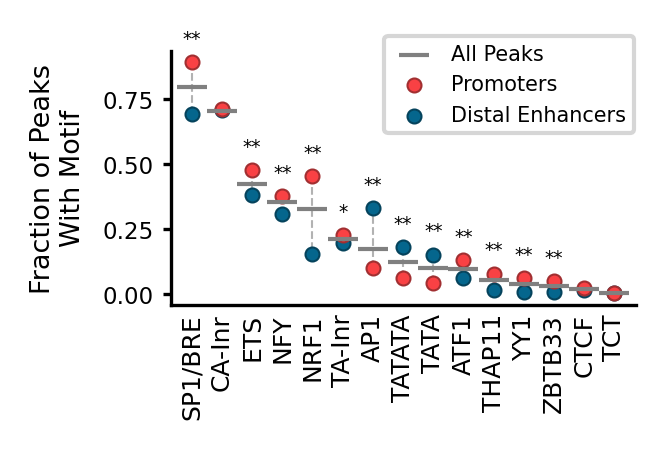

In [42]:
def plot_motif_enrichment_in_cCREs_condensed(motif_hit_counts, overlap_annots_bools,
                                             motif_names = motif_names,
                                             save_path = None):
    annots_to_plot = ["PLS", "dELS"]
    
    annots_to_labels = {"PLS" : "Promoters",
                        "pELS" : "Proximal Enhancers",
                        "dELS" : "Distal Enhancers"}
    
    annots_to_colors = {"All Peaks" : "gray", "PLS" : "#f94144", "dELS" : "#05668d"}
    annots_to_edgecolors = {"All Peaks" : "gray", "PLS" : "#A12F31", "dELS" : "#05435C"}
    annots_to_sizes = {"All Peaks" : 50, "PLS" : 45, "dELS" : 45}
    
    assert len(motif_names) == motif_hit_counts.shape[1]
    motif_indexes = range(len(motif_names))
    num_peaks = motif_hit_counts.shape[0]
    print("num_peaks:", num_peaks)
    
    # binarize motif hit counts in each peak: either a peak has the motif, or not
    
    motifs_in_peaks_binary = motif_hit_counts > 0
    
    # for each motif, compute:
    #  - the fraction of peaks with 1+ instances of that motif
    #  - the fraction of peaks *overlapping promoters* with 1+ instances of that motif
    #  - the fraction of peaks *overlapping enhancers* with 1+ instances of that motif
    #  - p-value for significance of the difference in motif-containing peak fractions,
    #      across promoters vs. enhancers
    
    annot_vals = defaultdict(lambda : [])  # this dict of lists collects motif fracs for each annot
    pvals = []  # collect pvals for each motif
    for motif_index in motif_indexes:
        total_peaks_with_motif = np.sum(motifs_in_peaks_binary[:, motif_index])
        print("num peaks with motif:", motif_names[motif_index], total_peaks_with_motif)
        
        annot_vals["All Peaks"].append(total_peaks_with_motif / num_peaks)
        
        for annot in annots_to_plot:
            num_overlap_peaks = np.sum(overlap_annots_bools[annot])
            num_overlap_peaks_with_motif = np.sum(motifs_in_peaks_binary[overlap_annots_bools[annot], motif_index])
            frac_peaks_with_motif_overlapping_annot = num_overlap_peaks_with_motif / num_overlap_peaks
            print("num_overlap_peaks_with_motif", motif_names[motif_index], annot, num_overlap_peaks_with_motif)
            
            annot_vals[annot].append(frac_peaks_with_motif_overlapping_annot)
        
        #mwu_pval = scipy.stats.mannwhitneyu(motifs_in_peaks_binary[ccre_annots["PLS"], motif_index],
        #                                    motifs_in_peaks_binary[ccre_annots["dELS"], motif_index]).pvalue
        
        fishers_exact_table = [[(motifs_in_peaks_binary[ccre_annots["PLS"], motif_index] == 0).sum(),
                                (motifs_in_peaks_binary[ccre_annots["PLS"], motif_index] == 1).sum()],
                               [(motifs_in_peaks_binary[ccre_annots["dELS"], motif_index] == 0).sum(),
                                (motifs_in_peaks_binary[ccre_annots["dELS"], motif_index] == 1).sum()]]
        
        print(fishers_exact_table)
        
        fishers_exact_pval = scipy.stats.fisher_exact(fishers_exact_table).pvalue
        
        #print(mwu_pval, fishers_exact_pval)
        if fishers_exact_pval <= 1e-19:
            pvals.append("**")
        elif fishers_exact_pval < 0.005:
            pvals.append("*")
        else:
            pvals.append(" ")
            
        print("Fishers exact p-val:", motif_names[motif_index], fishers_exact_pval)
            
        
    # what order to plot the motifs in: highest to lowest overall motif presence
    plot_order = np.argsort(annot_vals["All Peaks"])[::-1]
        
        
    plt.figure(figsize=(2.0, 1.1), dpi=300)
    
    # to avoid redundancy in the legend, only add labels to plotting actions once
    add_to_legend = True
    
    for y, plot_i in enumerate(plot_order):
        
        # first, plot the dashed line between the dots for promoters / enhancers
        
        plt.plot([y] * 2,
                 [annot_vals["PLS"][plot_i], annot_vals["dELS"][plot_i]],
                 color="gray", alpha = 0.6, linewidth=0.5, linestyle="dashed")
        
        # second, plot the marker for whether or not the diffences are significant above
        
        plt.text(y, 0.07 + max(annot_vals["PLS"][plot_i], annot_vals["dELS"][plot_i]),
                 pvals[plot_i],
                 fontsize=4.5, horizontalalignment="center")
        
        # third, plot the promoter/enhancer blue/red dots, and the gray marker for all
        
        for i, (key, vals) in enumerate(annot_vals.items()):
            if key == "All Peaks":
                # plot gray horizontal line marker for motif presence overall
                plt.scatter(y, vals[plot_i],
                            label=key if add_to_legend else "",
                            color=annots_to_colors[key],
                            linewidth=1,
                            s=annots_to_sizes[key],
                            zorder=10 - i, marker="_")
            else:
                # plot red/blue dot for promoter/enhancer motif presence
                plt.scatter(y, vals[plot_i],
                            label=annots_to_labels[key] if add_to_legend else "",
                            color=annots_to_colors[key],
                            edgecolor=annots_to_edgecolors[key],
                            linewidth=0.5,
                            s=annots_to_sizes[key],
                            zorder=10 - i, marker=".")
            
        add_to_legend = False  # everything has been added to legend once, so stop

    # aesthetics
        
    plt.legend(fontsize=5, loc="upper right", bbox_to_anchor=(1.02, 1.1))
    plt.ylabel("Fraction of Peaks\nWith Motif", fontsize=6.5)
    
    plt.xticks(motif_indexes, np.array(motif_names)[plot_order],
               fontsize=6, rotation=90)
    plt.yticks([0.0, 0.25, 0.5, 0.75], fontsize=5.5)
    plt.tick_params("y", length=2, pad=2)
    plt.tick_params("x", length=0, pad=2)
    
    plt.gca().spines[["top", "right"]].set_visible(False)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches = 'tight', pad_inches = 0.01, dpi = 300, transparent=True)
    
    plt.show()
    

plot_motif_enrichment_in_cCREs_condensed(motif_hit_counts["profile"], ccre_annots,
                                        save_path = figures_dir + "3C_ccre_motif_fracs.pdf")

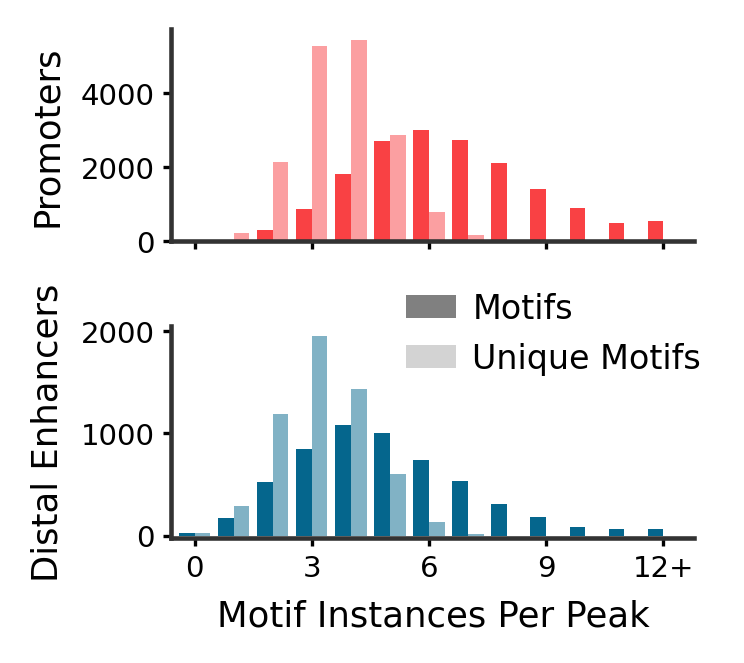

In [43]:
def plot_motif_complexity_across_ccres(motif_hit_counts, ccre_annots,
                                      save_path = None):
    annots_to_plot = ["PLS", "dELS"]
    
    annots_to_colors = {"PLS" : "#f94144", "dELS" : "#05668d"}

    annots_to_labels = {"PLS" : "Promoters",
                        "pELS" : "Proximal Enhancers",
                        "dELS" : "Distal Enhancers"}
    bar_width = 0.4
    
    # because a small number of peaks have 15 or 16 motifs (thanks, SP1),
    # we want to clip and have the last histogram bin just be like "12+"
    last_hist_bin = 12
    
    # will make 1 subplot for promoters, one for enhancers
    
    fig, axes = plt.subplots(2, 1, figsize=(2.25,2.2), dpi=300, sharex=True)
    fig.subplots_adjust(hspace=0.4)
    
    for ax_i, key in enumerate(annots_to_plot):
        # get motif hits in peaks overlapping cCRE annotation
        motif_hit_counts_annot = motif_hit_counts[ccre_annots[key]]
        
        # sum hits across all motifs (to get total # motif hits per peak)
        motif_hits_per_peak = motif_hit_counts_annot.sum(axis=1)

        # count how many times we see different counts of motifs in peaks
        hist_y, hist_x = np.histogram(motif_hits_per_peak,
                                      bins=range(np.max(motif_hits_per_peak) + 2))

        # clip histogram so the last 5 bins 
        
        hist_y = list(hist_y[:last_hist_bin]) + [np.sum(hist_y[last_hist_bin:])]
        hist_x = list(hist_x[:last_hist_bin]) + [last_hist_bin]

        axes[ax_i].bar(hist_x, hist_y, color=annots_to_colors[key], width=bar_width)
        
        # then repeat for *unique* motifs
        
        # sum hits across all motifs, after binarizing (to get total # unique motif hits per peak)
        uniq_hits_per_peak = (motif_hit_counts_annot > 0).sum(axis=1)

        hist_y2, hist_x2 = np.histogram(uniq_hits_per_peak,
                                        bins=range(np.max(uniq_hits_per_peak) + 2))
        
        axes[ax_i].bar(hist_x2[:-1] + bar_width, hist_y2,
                       color=annots_to_colors[key],
                       width=bar_width, alpha=0.5)

        # aesthetics
        
        axes[ax_i].set_ylabel(annots_to_labels[key], fontsize=8.5)
        
        if ax_i == len(annots_to_plot) - 1:
            axes[ax_i].set_xlabel("Motif Instances Per Peak", fontsize=8.5)
        
            xticklabels = []
            for i in hist_x:
                if i < last_hist_bin:
                    xticklabels.append(str(i))
                else:
                    xticklabels.append(str(last_hist_bin) + "+")

            axes[ax_i].set_xticks(np.array(hist_x[::3]) + bar_width / 2, xticklabels[::3])
            axes[ax_i].set_xlim(-bar_width, len(hist_x))
            
            # arbitrarily small negative value so the axis line doesn't cover small bars
            axes[ax_i].set_ylim(-20, axes[ax_i].get_ylim()[1])
            
        axes[ax_i].tick_params("x", labelsize=7, length=2, pad=2)
        axes[ax_i].tick_params("y", labelsize=7, length=2, pad=2)

        axes[ax_i].spines[["left", "bottom"]].set_linewidth(1.1)
        axes[ax_i].spines[["left", "bottom"]].set_color("#333333")
        axes[ax_i].spines[["top", "right"]].set_visible(False)


    legend_elements = [Patch(facecolor='gray', label='Motifs'),
                       Patch(facecolor='lightgray', label='Unique Motifs')]

    axes[-1].legend(handles=legend_elements, fontsize=8, bbox_to_anchor=(0,0,1.07,1.3),
                   loc='upper right', frameon=False, handletextpad=0.5, handlelength=1.5)
            
    if save_path is not None:
        plt.savefig(save_path, bbox_inches = 'tight', pad_inches = 0, dpi = 300, transparent=True)
    
    plt.show()


plot_motif_complexity_across_ccres(motif_hit_counts["profile"], ccre_annots,
                                  save_path = figures_dir + "3B_ccre_complexity.pdf")

## Can Motif Hits Distinguish cCREs?

In [44]:
# To stratify performance across folds, we need to label
# each test example with which fold it was in the test set for.

# Fold assignment (below) needs to match what was in
# 1_process_data/_split_peaks_train_val_test.py

FOLDS = [["chr1", "chr4"],
         ["chr2", "chr13", "chr16"],
         ["chr5", "chr6", "chr20", "chr21"],
         ["chr7", "chr8", "chr9"],
         ["chr10", "chr11", "chr12"],
         ["chr3", "chr14", "chr15", "chr17"],
         ["chr18", "chr19", "chr22", "chrX", "chrY"]]

def get_fold_label(chrom):
    # returns *0-indexed* fold num that this chromosome was in the test set for
    for fold_i, fold_chroms in enumerate(FOLDS):
            if chrom in fold_chroms:
                return fold_i
    return -1

def make_fold_labels(coords):
    # Make list of len [num_peaks] / length of all_peak_path file,
    # where entry i is the fold that example i was in the test set for.
    
    # coord[0] is the chromosome (first column from bed file)
    fold_labels = [get_fold_label(coord[0]) for coord in coords]
    
    # check we assigned a fold for every single example/peak
    assert all([label > -1 for label in fold_labels]), fold_labels
    return np.array(fold_labels)

fold_labels = make_fold_labels(coords)

In [45]:
# try fitting a logistic regression model to predict promoter vs. enhancer
# using motif hit counts

def print_motif_coefficients(coefs, motif_names = motif_names):
    sort_order = np.argsort(np.abs(coefs))[::-1]
    for sort_i in sort_order:
        print(motif_names[sort_i], coefs[sort_i])

def get_classifier_acc_over_folds(predictor_array, to_predict, fold_labels):
    fold_accs_imbalanced = []
    fold_accs_balanced = []
    for fold_i in range(len(FOLDS)):
        assert len(to_predict) == len(fold_labels), (len(to_predict), len(fold_labels))
        assert len(predictor_array) == len(fold_labels), (len(predictor_array), len(fold_labels))
        
        to_predict_train = to_predict[fold_labels != fold_i]
        to_predict_test = to_predict[fold_labels == fold_i]
        predictor_array_train = predictor_array[fold_labels != fold_i]
        predictor_array_test = predictor_array[fold_labels == fold_i]

        lrm = LogisticRegression(penalty=None).fit(predictor_array_train, to_predict_train)
        
        acc = lrm.score(predictor_array_test, to_predict_test)
        fold_accs_imbalanced.append(acc)
        
        print_motif_coefficients(lrm.coef_[0])
        
        # repeat, but with test set balanced
        # (since balancing the test set uses random sampling, repeat and average)
        accs_rand = []
        for _ in range(5):
            balanced_test_mask = get_balanced_sample_bools(to_predict_test)
            to_predict_test_balanced = to_predict_test[balanced_test_mask]
            predictor_array_test_balanced = predictor_array_test[balanced_test_mask]
        
            acc = lrm.score(predictor_array_test_balanced, to_predict_test_balanced)
            accs_rand.append(acc)
            
        fold_accs_balanced.append(np.mean(accs_rand))

    return np.mean(fold_accs_imbalanced), np.mean(fold_accs_balanced)


either_promoter_or_enhancer_peaks = np.logical_or(ccre_annots["PLS"], ccre_annots["dELS"])
motif_hit_counts_ccres = motif_hit_counts["profile"][either_promoter_or_enhancer_peaks]
promoter_labels = ccre_annots["PLS"][either_promoter_or_enhancer_peaks]
fold_labels_promoters_or_enhancers = fold_labels[either_promoter_or_enhancer_peaks]

mean_acc, mean_acc_balanced = get_classifier_acc_over_folds(motif_hit_counts_ccres, promoter_labels,
                                         fold_labels_promoters_or_enhancers)

print("Accuracy of LR classifier (promoter vs. enhancer):")
print(mean_acc, mean_acc_balanced)

YY1 1.9618972632182816
ZBTB33 1.3033820280270474
THAP11 1.2682069280456019
AP1 -0.9174555548737051
NRF1 0.9004541982716079
ATF1 0.7590977296709718
TATA -0.7056191168024648
TATATA -0.5443961443535323
TCT 0.46969835699116247
ETS 0.4245253471092027
NFY 0.36864431275566945
SP1/BRE 0.3126986692055603
TA-Inr 0.1673854899536925
CA-Inr 0.1273861316545553
CTCF 0.009514511002522928
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
YY1 1.933901996348831
ZBTB33 1.4155005256375717
THAP11 1.2633864677201827
NRF1 0.8941658988940859
AP1 -0.854688117614861
ATF1 0.7715496235037815
TATA -0.7241319320769706
TCT 0.6196432470372615
TATATA -0.48483372177058026
ETS 0.42470013472779616
NFY 0.36494341452987117
SP1/BRE 0.31360286881802646
CTCF 0.15971914831905204
TA-Inr 0.1476858507760613
CA-Inr 0.1012734778469497
Subsampling 618 samples from 2157
Subsampling 618 samples from 2157
Subsampling 6

In [46]:
# try again, but this time, binarize motif hits (1+ motif hits = 1, 0 otherwise)

mean_acc, mean_acc_balanced = get_classifier_acc_over_folds(motif_hit_counts_ccres > 0, promoter_labels,
                                         fold_labels_promoters_or_enhancers)

print("Accuracy of LR classifier (promoter vs. enhancer), binarized motif hits:")
print(mean_acc, mean_acc_balanced)

YY1 2.0929538419507137
THAP11 1.5196203796881458
ZBTB33 1.3985419654365003
NRF1 1.3214065154337251
AP1 -1.1976935458299627
SP1/BRE 1.1580618024994698
TATA -0.959208611800619
ATF1 0.7346542363424612
TATATA -0.7016964123304065
TCT 0.6656870334216426
NFY 0.45698544743296277
ETS 0.4378833752612981
TA-Inr 0.17917717574853254
CA-Inr 0.1308762006305311
CTCF 0.02965962771221337
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
Subsampling 790 samples from 2351
YY1 2.0521148713343504
ZBTB33 1.5711087013503164
THAP11 1.5239335249821293
NRF1 1.3117377374286645
AP1 -1.130156121829456
SP1/BRE 1.129661676646649
TATA -0.9582701106133273
TCT 0.8028522471950325
ATF1 0.7476418421036551
TATATA -0.6612479665840294
ETS 0.40938245790234534
NFY 0.38702975625483216
CTCF 0.20770505802234404
TA-Inr 0.13526442552450357
CA-Inr 0.09055240339010116
Subsampling 618 samples from 2157
Subsampling 618 samples from 2157
Subsampling 618

## Motif Instance Similarity to CWM Across cCREs

PLS n: SP1/BRE 45595
dELS n: SP1/BRE 9200
MWU p-val: SP1/BRE 1.045674381940062e-186
PLS n: CA-Inr 17598
dELS n: CA-Inr 5785
MWU p-val: CA-Inr 5.4658623284723e-56
PLS n: ETS 12290
dELS n: ETS 2791
MWU p-val: ETS 3.196886738083249e-73
PLS n: NFY 10755
dELS n: NFY 2409
MWU p-val: NFY 1.5412932997001694e-49
PLS n: NRF1 11186
dELS n: NRF1 1163
MWU p-val: NRF1 1.3329182290071874e-18
PLS n: ATF1 2472
dELS n: ATF1 392
MWU p-val: ATF1 1.7027794953589266e-11
PLS n: TATA 764
dELS n: TATA 965
MWU p-val: TATA 0.10976430073427136
PLS n: THAP11 1816
dELS n: THAP11 119
MWU p-val: THAP11 7.189951816762913e-08
PLS n: YY1 1077
dELS n: YY1 46
MWU p-val: YY1 1.4755451892474842e-05
PLS n: AP1 1891
dELS n: AP1 2373
MWU p-val: AP1 6.685477874287101e-27
PLS n: TA-Inr 4376
dELS n: TA-Inr 1265
MWU p-val: TA-Inr 0.011267789519972855
PLS n: CTCF 396
dELS n: CTCF 110
MWU p-val: CTCF 0.37242775018423346
PLS n: ZBTB33 997
dELS n: ZBTB33 60
MWU p-val: ZBTB33 1.247504581066786e-06
PLS n: TCT 76
dELS n: TCT 22
MWU p-val

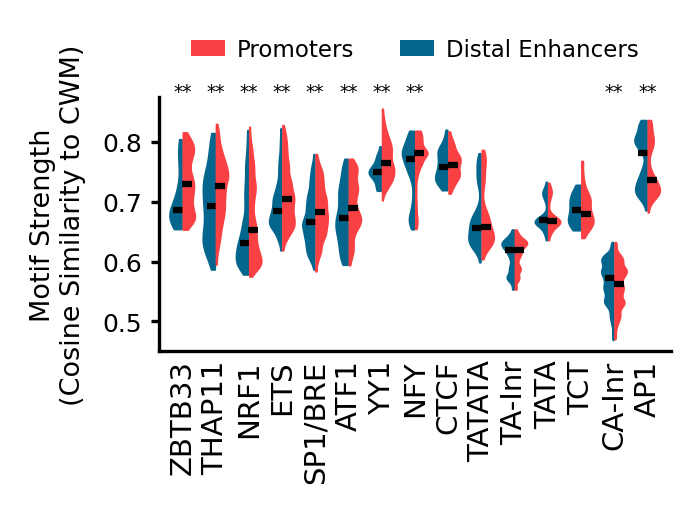

In [47]:
def score_seq_by_cwm(cwm, seq):
    # this computes the cosine similarity between the cwm matrix
    # and the sequence in its one-hot encoding form.
    
    # if seq is not already one-hot encoded, encode
    if type(seq) == str:
        seq = one_hot_encode(seq)
        
    assert cwm.shape == seq.shape
    
    # numerator = dot product, denominator = product of magnitudes
    return np.multiply(seq, cwm).sum() / (np.linalg.norm(seq) * np.linalg.norm(cwm))


def extract_seqs_at_motifs(motif_hits, coords, onehot_seqs, in_window, buffer_width = 200):
        
    assert len(onehot_seqs.shape) == 3 and onehot_seqs.shape[1] == 4, onehot_seqs.shape
    seq_len = onehot_seqs.shape[-1]
    
    def convert_motif_coords_to_seq_coords(coords, peak_indexes, motif_starts, motif_ends):
        # motif hits are represented as genomic coordinates, but we need to know where
        # in the sequence centered at a PRO-cap peak they were found, in order to extract
        # the actual sequence at that position.
        real_starts = []
        real_ends = []
        for peak_index, start, end in zip(peak_indexes, motif_starts, motif_ends):
            peak_coords = coords[peak_index]
            peak_start, peak_end = peak_coords[1:3]
            # subtract genomic start coordinate of peak from the genomic start coord of motif,
            # to get where in the peak sequence window the motif is
            real_start = start - peak_start# - (in_window - seq_len) // 2  # please be the same
            real_starts.append(real_start)
            real_ends.append(real_start + (end - start))

        return np.array(real_starts), np.array(real_ends)
        
    peak_indexes = motif_hits["peak_index"]
    # because the hit caller pads by 2...
    genomic_motif_starts = motif_hits["start"] - 2
    genomic_motif_ends = motif_hits["end"] + 2
    
    motif_rcs = motif_hits["strand"] == "-"
    
    motif_starts, motif_ends = convert_motif_coords_to_seq_coords(coords, peak_indexes,
                                                                  genomic_motif_starts,
                                                                  genomic_motif_ends)

    # For each seqlet, fetch the actual sequence at that location
    motif_seqs = []
    for peak_index, motif_start, motif_end, rc in zip(peak_indexes, motif_starts, motif_ends, motif_rcs):
        motif_mid = (motif_start + motif_end) // 2
        assert not (motif_mid - buffer_width < 0 or motif_mid + buffer_width > seq_len)
        
        seq = onehot_seqs[peak_index, :, motif_start:motif_end]
        
        # if the motif was found in orientation opposite the CWM, flip
        if rc:
            seq = seq[::-1, ::-1]
        motif_seqs.append(seq)
    
    motif_seqs = np.stack(motif_seqs)
    return motif_seqs


def calc_motif_strengths(modisco_results_path, onehot_seqs, patterns_to_keep,
                         motif_hits, coords, in_window, prof_width=200):

    modisco_results = load_modisco_results(modisco_results_path)
    
    pattern_type = "pos_patterns"
    patterns = modisco_results[pattern_type]

    # for each motif...
    # (in modisco results, motifs are named by a pattern index)
    cwm_score_list = []
    for ax_row_i, pattern_i in enumerate(patterns_to_keep):
        pattern_name = "pattern_" + str(pattern_i)
        pattern = patterns[pattern_name]

        # remove the extra, low-IC bases modisco adds to all hits
        cwm_trimmed = trim_motif_by_thresh(pattern["contrib_scores"][:], trim_threshold=0.2, pad=2)
        cwm_trimmed = cwm_trimmed / np.sum(cwm_trimmed)
        
        # do ax_row_i here because the motif hit caller only saw filtered subset of motifs
        motif_hits_subset = motif_hits[motif_hits["motif_index"] == ax_row_i]
        
        # get the actual genomic sequences at every motif instance
        motif_seqs = extract_seqs_at_motifs(motif_hits_subset, coords,
                                            onehot_seqs, in_window, buffer_width=prof_width)

        # calculate how close the motif instances match the CWM for the motif
        seq_scores = np.array([score_seq_by_cwm(cwm_trimmed, seq.T) for seq in motif_seqs])
        cwm_score_list.append(seq_scores)
        
    return cwm_score_list


def subset_motif_hits_by_ccre(motif_hits, ccre_bools):
    # takes the set of motif hits over the entire dataset (a pandas dataframe),
    # and filters for only the ones found in the peaks overlapping a cCRE
    peak_indexes_with_ccre = np.where(ccre_bools)[0]
    return motif_hits[motif_hits["peak_index"].isin(peak_indexes_with_ccre)]


def make_violinplot_halved(violinplot, color, left=False):
    # converts a matplotlib violinplot object to just half of a violinplot
    #  - if left=True, draws the left half; by default, draws the right half
    
    for b in violinplot['bodies']:
        # get the center
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        
        if left:
            # modify the paths to not go further right than the center
            b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], - np.inf, m)
        else:
            # modify the paths to not go further left than the center
            b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], m, np.inf)

        b.set_edgecolor(color)
        b.set_facecolor(color)
        b.set_alpha(1)
        b.set_linewidth(0.5)
        
        
def plot_motif_strengths_by_ccre(modisco_results_path, onehot_seqs,
                                 patterns_to_keep, motif_hits, coords,
                                 in_window, ccre_annots, save_path=None):
    
    annots_to_colors = {"PLS" : "#f94144", "dELS" : "#05668d"}

    annots_to_labels = {"PLS" : "Promoters",
                        "dELS" : "Distal Enhancers"}
    
    all_motif_strengths = dict()
    median_motif_strengths = dict()
    
    for annot in ["PLS", "dELS"]:
        # get all motif hits in PRO-cap peaks overlapping this cCRE type
        motif_hits_for_annot = subset_motif_hits_by_ccre(motif_hits, ccre_annots[annot])

        # calculate how similar each motif hit is to the CWM for the motif
        motif_strengths = calc_motif_strengths(modisco_results_path, onehot_seqs,
                                               patterns_to_keep, motif_hits_for_annot,
                                               coords, in_window)
        
        all_motif_strengths[annot] = np.array(motif_strengths, dtype=object)
        median_motif_strengths[annot] = np.array([np.median(strengths) for strengths in motif_strengths])
    
    # the x-axis ordering should go from most to least enriched in promoters
    plot_order = np.argsort(median_motif_strengths["dELS"] - median_motif_strengths["PLS"])
    num_motifs = len(all_motif_strengths["PLS"])
    
    # calculate significance of the difference in motif strengths
    # between promoters and enhancers, for each motif
    
    
    pvals = []
    for motif_i in range(num_motifs):
        print("PLS n:", motif_names[motif_i], all_motif_strengths["PLS"][motif_i].shape[0])
        print("dELS n:", motif_names[motif_i], all_motif_strengths["dELS"][motif_i].shape[0])
        
        mwu_pval = scipy.stats.mannwhitneyu(all_motif_strengths["PLS"][motif_i],
                                         all_motif_strengths["dELS"][motif_i]).pvalue
        
        if mwu_pval < 0.0001:
            pvals.append("**")
        elif mwu_pval < 0.01:
            pvals.append("*")
        else:
            pvals.append(" ")
            
        print("MWU p-val:", motif_names[motif_i], mwu_pval)
            
    pvals = np.array(pvals)[plot_order]

    
    plt.figure(figsize=(2.2,1.1), dpi=300)

    v2 = plt.violinplot(all_motif_strengths["dELS"][plot_order], points=500,
                       positions=np.arange(num_motifs) - 0.03,
                       showmeans=False, showextrema=False, showmedians=False,
                       widths=0.7)
    
    make_violinplot_halved(v2, annots_to_colors["dELS"], left=True)

    plt.scatter(np.arange(num_motifs) - 0.12, median_motif_strengths["dELS"][plot_order],
                marker="_", c="k", s=5, zorder=1)
    
    
    v1 = plt.violinplot(all_motif_strengths["PLS"][plot_order], points=500,
                       positions=np.arange(num_motifs) + 0.02,
                       showmeans=False, showextrema=False, showmedians=False,
                       widths=0.7)
    
    make_violinplot_halved(v1, annots_to_colors["PLS"])

    # draw on medians for each violinplot
    plt.scatter(np.arange(num_motifs) + 0.14, median_motif_strengths["PLS"][plot_order],
                marker="_", c="k", s=5, zorder=1)
    

    # draw pval indicators
    for i in range(len(pvals)):
        plt.text(i, plt.gca().get_ylim()[1], pvals[i],
                 fontsize=4.5, horizontalalignment="center")
    
    # aesthetics
    
    plt.ylabel("Motif Strength\n(Cosine Similarity to CWM)", fontsize=6.5)
    
    plt.xticks(np.arange(num_motifs), np.array(motif_names)[plot_order],
               rotation=90, fontsize=7)
    
    plt.tick_params("x", length=0, pad=2)
    plt.tick_params("y", labelsize=6, length=2, pad=2)
    plt.xlim(-0.7, num_motifs - 0.3)
    
    plt.gca().spines[["top", "right"]].set_visible(False)

    legend_elements = [Patch(facecolor=annots_to_colors["PLS"], label='Promoters'),
                       Patch(facecolor=annots_to_colors["dELS"], label='Distal Enhancers')]

    plt.legend(handles=legend_elements, fontsize=5.5, bbox_to_anchor=(0.5, 1.06), ncol=2,
                   loc='lower center', frameon=False, handletextpad=0.5, handlelength=1.5)
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches = 'tight', pad_inches = 0.01, dpi = 300, transparent=True)
    
    plt.show()
        
        
plot_motif_strengths_by_ccre(config.modisco_profile_results_path, onehot_seqs,
                             patterns_to_keep, motif_hits["profile"], coords,
                             in_window, ccre_annots,
                             save_path=figures_dir + "3D_ccre_motif_strengths.pdf")

## Promoter-Only Model Analysis

In [ ]:
# earlier scripts trained extra model sets (with cross-val):
#  - one with only promoters in the training set
#  - one with just a different random seed than the OG models

promoters_only_timestamps = ["2024-01-11_04-16-09", "2024-01-11_05-41-04",
                             "2024-01-11_06-46-15", "2024-01-11_07-54-30",
                             "2024-01-11_09-03-11", "2024-01-11_10-25-53",
                             "2024-01-11_11-44-28"]

repeat_timestamps = ["2024-02-18_01-26-07", "2024-02-18_03-00-29",
                     "2024-02-18_04-50-55", "2024-02-18_06-47-37",
                     "2024-02-18_08-43-12", "2024-02-18_10-37-54",
                     "2024-02-18_12-18-54"]

timestamps = ["2023-05-29_15-51-40",
              "2023-05-29_15-58-41",
              "2023-05-29_15-59-09",
              "2023-05-30_01-40-06",
              "2023-05-29_23-21-23",
              "2023-05-29_23-23-45",
              "2023-05-29_23-24-11"]


def load_fold_configs(timestamps, model_type = "strand_merged_umap"):
    data_type = "procap"
    cell_type = "K562"
    
    configs = []
    for i, timestamp in enumerate(timestamps):
        fold = str(i + 1)
        if "promoters_only" in model_type:
            config = PromotersOnlyFoldFilesConfig(cell_type, model_type, fold, timestamp, data_type)
        else:
            config = FoldFilesConfig(cell_type, model_type, fold, timestamp, data_type)
            
        configs.append(config)
    return configs

promoters_only_fold_configs = load_fold_configs(promoters_only_timestamps,
                                                model_type = "promoters_only_strand_merged_umap")

repeat_fold_configs = load_fold_configs(repeat_timestamps, model_type = "strand_merged_umap_replicate")
original_fold_configs = load_fold_configs(timestamps)

In [ ]:
def load_pred_logcounts(config):
    return np.load(config.pred_logcounts_test_path).squeeze()

def load_pred_profiles_flat(config):
    return np.exp(np.load(config.pred_profiles_test_path)).squeeze().flatten()


def get_preds_corrs_one_fold(config1, config2, profile=False):
    if profile:
        preds1 = load_pred_profiles_flat(config1)
        preds2 = load_pred_profiles_flat(config2)
    else:
        preds1 = load_pred_logcounts(config1)
        preds2 = load_pred_logcounts(config2)
    
    assert preds1.shape == preds2.shape
    
    pearson = np.corrcoef(preds1, preds2)[0,1]
    spearman = spearmanr(preds1, preds2).correlation
    return pearson, spearman
    
    
def get_stddevs_corrs_all_folds(configs1, configs2, profile=False):
    corrs = []
    for config1, config2 in zip(configs1, configs2):
        corrs.append(get_preds_corrs_one_fold(config1, config2, profile=profile))
        
    pearsons, spearmans = zip(*corrs)
    return np.std(pearsons), np.std(spearmans) 


def get_pvals_corrs_all_folds(configs1, configs2, replicate_configs2, profile=False):
    corrs_expt = []
    for config1, config2 in zip(configs1, configs2):
        corrs_expt.append(get_preds_corrs_one_fold(config1, config2, profile=profile))
    pearsons_expt, spearmans_expt = zip(*corrs_expt) 
        
    corrs_replicate = []
    for config2, config3 in zip(configs2, replicate_configs2):
        corrs_replicate.append(get_preds_corrs_one_fold(config2, config3, profile=profile))
    pearsons_replicate, spearmans_replicate = zip(*corrs_replicate) 
    
    pearson_pval = scipy.stats.wilcoxon(pearsons_expt, pearsons_replicate).pvalue
    spearman_pval = scipy.stats.wilcoxon(spearmans_expt, spearmans_replicate).pvalue

    return pearson_pval, spearman_pval


def get_preds_corrs_all_folds(configs1, configs2, profile=False):
    preds1 = []
    preds2 = []
    for config1, config2 in zip(configs1, configs2):
        if profile:
            preds1.extend(load_pred_profiles_flat(config1))
            preds2.extend(load_pred_profiles_flat(config2))
        else:
            preds1.extend(load_pred_logcounts(config1))
            preds2.extend(load_pred_logcounts(config2))
    
    preds1 = np.array(preds1)
    preds2 = np.array(preds2)
    assert preds1.shape == preds2.shape
    
    pearson = np.corrcoef(preds1, preds2)[0,1]
    spearman = spearmanr(preds1, preds2).correlation
    return pearson, spearman


def calc_everything(configs1, configs2, replicate_configs2):
    stats = defaultdict(lambda : defaultdict(lambda : defaultdict( lambda : dict())))
    for task in [False, True]:
        if task:
            print("\n===   Profile Task   ===")
        else:
            print("\n===   Counts Task   ===")
    
        print("\nPromoter vs. Original:")
    
        pearson, spearman = get_preds_corrs_all_folds(configs1, configs2, profile=task)
        stats["promoter_vs_original"][task]["corr"]["pearson"] = pearson
        stats["promoter_vs_original"][task]["corr"]["spearman"] = spearman
        print("Corrs:   \t%0.3f\t%0.3f" % (pearson, spearman))
    
        pearson, spearman = get_stddevs_corrs_all_folds(configs1, configs2, profile=task)
        stats["promoter_vs_original"][task]["stddev"]["pearson"] = pearson
        stats["promoter_vs_original"][task]["stddev"]["spearman"] = spearman
        print("Std devs:\t%0.3f\t%0.3f" % (pearson, spearman))
        
        print("\nReplicate vs. Original:")
        
        pearson, spearman = get_preds_corrs_all_folds(replicate_configs2, configs2, profile=task)
        stats["replicate_vs_original"][task]["corr"]["pearson"] = pearson
        stats["replicate_vs_original"][task]["corr"]["spearman"] = spearman
        print("Corrs:   \t%0.3f\t%0.3f" % (pearson, spearman))
    
        pearson, spearman = get_stddevs_corrs_all_folds(replicate_configs2, configs2, profile=task)
        stats["replicate_vs_original"][task]["stddev"]["pearson"] = pearson
        stats["replicate_vs_original"][task]["stddev"]["spearman"] = spearman
        print("Std devs:\t%0.3f\t%0.3f" % (pearson, spearman))

        pearson, spearman = get_pvals_corrs_all_folds(configs1, configs2, replicate_configs2, profile=task)
        stats["pvals"][task]["pearson"] = pearson
        stats["pvals"][task]["spearman"] = spearman
        print("\nP-values:\t%0.3f\t%0.3f" % (pearson, spearman))
        
    return stats

        
promoter_only_model_stats = calc_everything(promoters_only_fold_configs, original_fold_configs, repeat_fold_configs)

In [ ]:
def load_deepshaps(config, profile=False):
    if profile:
        scores = np.load(config.profile_onehot_scores_path).sum(axis=1)
    else:
        scores = np.load(config.counts_onehot_scores_path).sum(axis=1)
        
    # slicing to central 1000bp because there probably won't be much past that
    scores = scores[..., in_window // 2 - 500 : in_window // 2 + 500].flatten()
    return scores


def get_attrs_corrs_one_fold(config1, config2, profile=False):
    scores1 = load_deepshaps(config1, profile=profile)
    scores2 = load_deepshaps(config2, profile=profile)
    
    assert scores1.shape == scores2.shape
    
    pearson = np.corrcoef(scores1, scores2)[0,1]
    spearman = spearmanr(scores1, scores2).correlation
    return pearson, spearman
    
    
def get_stddevs_attrs_corrs_all_folds(configs1, configs2, profile=False):
    corrs = []
    for config1, config2 in zip(configs1, configs2):
        corrs.append(get_attrs_corrs_one_fold(config1, config2, profile=profile))
        
    pearsons, spearmans = zip(*corrs)
    return np.std(pearsons), np.std(spearmans) 


def get_pvals_attrs_corrs_all_folds(configs1, configs2, replicate_configs2, profile=False):
    corrs_expt = []
    for config1, config2 in zip(configs1, configs2):
        corrs_expt.append(get_attrs_corrs_one_fold(config1, config2, profile=profile))
    pearsons_expt, spearmans_expt = zip(*corrs_expt) 
        
    corrs_replicate = []
    for config2, config3 in zip(configs2, replicate_configs2):
        corrs_replicate.append(get_attrs_corrs_one_fold(config2, config3, profile=profile))
    pearsons_replicate, spearmans_replicate = zip(*corrs_replicate) 
    
    pearson_pval = scipy.stats.wilcoxon(pearsons_expt, pearsons_replicate).pvalue
    spearman_pval = scipy.stats.wilcoxon(spearmans_expt, spearmans_replicate).pvalue

    return pearson_pval, spearman_pval


def get_attrs_corrs_all_folds(configs1, configs2, profile=False):
    scores1 = []
    scores2 = []
    for config1, config2 in zip(configs1, configs2):
        scores1.extend(load_deepshaps(config1, profile=profile))
        scores2.extend(load_deepshaps(config2, profile=profile))
    
    scores1 = np.array(scores1)
    scores2 = np.array(scores2)
    assert scores1.shape == scores2.shape
    
    pearson = np.corrcoef(scores1, scores2)[0,1]
    spearman = spearmanr(scores1, scores2).correlation
    return pearson, spearman


def calc_everything_scores(configs1, configs2, replicate_configs2):
    stats = defaultdict(lambda : defaultdict(lambda : defaultdict( lambda : dict())))
    for task in [False, True]:
        if task:
            print("\n===   Profile Task   ===")
        else:
            print("\n===   Counts Task   ===")
    
        print("\nPromoter vs. Original:")
    
        pearson, spearman = get_attrs_corrs_all_folds(configs1, configs2, profile=task)
        stats["promoter_vs_original"][task]["corr"]["pearson"] = pearson
        stats["promoter_vs_original"][task]["corr"]["spearman"] = spearman
        print("Corrs:   \t%0.3f\t%0.3f" % (pearson, spearman))
    
        pearson, spearman = get_stddevs_attrs_corrs_all_folds(configs1, configs2, profile=task)
        stats["promoter_vs_original"][task]["stddev"]["pearson"] = pearson
        stats["promoter_vs_original"][task]["stddev"]["spearman"] = spearman
        print("Std devs:\t%0.3f\t%0.3f" % (pearson, spearman))
        
        print("\nReplicate vs. Original:")
        
        pearson, spearman = get_attrs_corrs_all_folds(replicate_configs2, configs2, profile=task)
        stats["replicate_vs_original"][task]["corr"]["pearson"] = pearson
        stats["replicate_vs_original"][task]["corr"]["spearman"] = spearman
        print("Corrs:   \t%0.3f\t%0.3f" % (pearson, spearman))
    
        pearson, spearman = get_stddevs_attrs_corrs_all_folds(replicate_configs2, configs2, profile=task)
        stats["replicate_vs_original"][task]["stddev"]["pearson"] = pearson
        stats["replicate_vs_original"][task]["stddev"]["spearman"] = spearman
        print("Std devs:\t%0.3f\t%0.3f" % (pearson, spearman))

        pearson, spearman = get_pvals_attrs_corrs_all_folds(configs1, configs2, replicate_configs2, profile=task)
        stats["pvals"][task]["pearson"] = pearson
        stats["pvals"][task]["spearman"] = spearman
        print("\nP-values:\t%0.3f\t%0.3f" % (pearson, spearman))
        
    return stats

        
promoter_only_model_stats_scores = calc_everything_scores(promoters_only_fold_configs,
                                                          original_fold_configs,
                                                          repeat_fold_configs)

In [ ]:
def print_table(stats, stats_scores):
    # to make life easier, this function prints out all the info
    # calculated above in the form of a latex table, so I can just
    # copy-paste the whole thing into overleaf if numbers change.
    
    rownames = ["Counts Predictions", "Profile Predictions",
                "Counts Contribution Scores", "Profile Contribution Scores"]
    
    row1 = []
    row2 = []
    row3 = []
    row4 = []
    for comparison in ["replicate_vs_original", "promoter_vs_original"]:
        for correlation_type in ["pearson", "spearman"]:
            for corr_or_stddev in ["corr", "stddev"]:
                # counts, then profile
                row1.append(stats[comparison][False][corr_or_stddev][correlation_type])
                row2.append(stats[comparison][True][corr_or_stddev][correlation_type])
                
                row3.append(stats_scores[comparison][False][corr_or_stddev][correlation_type])
                row4.append(stats_scores[comparison][True][corr_or_stddev][correlation_type])
                
    rows_data = [row1, row2, row3, row4]
    
    for row_i, (row_data, rowname) in enumerate(zip(rows_data, rownames)):
        row_means = [val for col_i, val in enumerate(row_data) if col_i % 2 == 0]
        row_stddevs = [val for col_i, val in enumerate(row_data) if col_i % 2 == 1]
        
        row_as_str = [rowname]
        for mean, stddev in zip(row_means, row_stddevs):
            row_as_str.append("%0.3f" % (mean) + " (%0.3f)" % (stddev))
        
        row_as_str = " & ".join(row_as_str)
        
        if row_i < len(rows_data) - 1:
            print(row_as_str + r' \\')
        else:
            print(row_as_str + r'\label{Tab2}\\')

print_table(promoter_only_model_stats, promoter_only_model_stats_scores)

In [ ]:
def get_pred_counts_all_folds(configs, spearman=False):
    pred_counts = []
    for config in configs:
        loaded_preds = np.load(config.pred_logcounts_test_path).squeeze()
        pred_counts.extend(np.exp(loaded_preds))
    return np.array(pred_counts)

promoters_only_pred_counts = get_pred_counts_all_folds(promoters_only_fold_configs)
original_pred_counts = get_pred_counts_all_folds(original_fold_configs)

In [ ]:
def get_sort_order_test_sets(cell_type, model_type, data_type):
    # the way I loaded in the test sets fold-by-fold,
    # the examples are not in the same order as the all_peaks_bed file order
    # so this function figures out how to reorder the test set data
    
    test_coords = []
    
    for fold_0_index, timestamp in enumerate(timestamps):
        fold = str(fold_0_index + 1)
        config = FoldFilesConfig(cell_type, model_type, fold, timestamp, data_type)
        
        test_coords.extend(load_coords(config.test_peak_path, in_window))
        
    # this contains the same coords at test_coords, but in the correct order this time
    merged_config = MergedFilesConfig(cell_type, model_type, data_type)
    all_coords = load_coords(merged_config.all_peak_path, in_window)
    
    sort_order = [test_coords.index(coord) for coord in all_coords]
    assert np.all(np.array(all_coords) == np.array(test_coords)[sort_order])
    
    return sort_order

sort_order = get_sort_order_test_sets(cell_type, model_type, data_type)
sorted_promoters_only_pred_counts = promoters_only_pred_counts[sort_order]
sorted_original_pred_counts = original_pred_counts[sort_order]

In [ ]:
def plot_counts_scatter(promoter_model_counts, normal_model_counts, color_by,
                             title = None, save_path = None, xlabel = None, ylabel = None):

    annots_to_colors = {"All Peaks" : "gray", "PLS" : "#f94144", "dELS" : "#05668d"}
    
    promoter_model_counts = promoter_model_counts.squeeze().flatten()
    normal_model_counts = normal_model_counts.squeeze().flatten()
    
    assert promoter_model_counts.shape == normal_model_counts.shape
    
    pearson_r = np.corrcoef(np.log(promoter_model_counts),
                            np.log(normal_model_counts))[0,1]
    
    plot_params = {
        "xtick.labelsize": 6,
        "ytick.labelsize": 6
    }
    plt.rcParams.update(plot_params)

    plt.figure(figsize=(1.25,1.25), dpi=500)

    colors = np.array(["#000000" for _ in range(len(color_by))])
    colors[color_by] = annots_to_colors["dELS"]
    plt.scatter(promoter_model_counts[~color_by], normal_model_counts[~color_by], c="k",
                alpha = 0.05, s = 1, linewidths=0, rasterized=True)
    plt.scatter(promoter_model_counts[color_by], normal_model_counts[color_by], c="#0174DF",
                alpha = 0.05, s = 1, linewidths=0, label="Distal\nEnhancers", rasterized=True)

    plt.semilogy()
    plt.semilogx()

    max_lim = max(plt.gca().get_xlim()[1], plt.gca().get_ylim()[1])
    min_lim = min(plt.gca().get_xlim()[0], plt.gca().get_ylim()[0])
    #plt.ylim(min_lim, max_lim)
    plt.xlim(60, plt.gca().get_xlim()[1])

    if xlabel is not None:
        plt.xlabel(xlabel, fontsize=7)
    if ylabel is not None:
        plt.ylabel(ylabel, fontsize=7)

    if pearson_r is not None:
        print(pearson_r)
        plt.text(60 * 1.4, max_lim * 0.31,
                 "Pearson\n" + r'$r = %0.2f$' % pearson_r,
                 fontsize=5)

    ax = plt.gca()
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.legend(handles=[Line2D([0], [0], marker='o', color='w',
                               label='Distal Enhancers', markeredgewidth=0,
                          markerfacecolor='#0174DF', markersize=3.5)],
               fontsize=5, loc="upper center", handletextpad=0, frameon=False, 
               bbox_to_anchor=(0.5,1.2))
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches = 'tight', pad_inches = 0, dpi=500, transparent=True)
        
    #plt.gca().set_aspect('equal', 'box')
    plt.show()
    
plot_counts_scatter(sorted_promoters_only_pred_counts,
                    sorted_original_pred_counts,
                    ccre_annots["dELS"],
                   xlabel = "Promoter-ProCapNet\nPred. Reads",
                   ylabel = "ProCapNet Pred. Reads",
                    save_path = figures_dir + "3E_promoters_only_model_preds_scatter.pdf")  